## Introduction to Convolutional Neural Networks and Computer Vision

#### Get the data

The images we're working with are from the Food101 dataset (101 different classes of food)
However we've modified it to only use two classes (pizza & steak) using the image data modification notebook

We start with a smaller dataset so we can experiment quickly and figure what works (or better yet what doesn't work before scaling up.)

In [1]:
# import zipfile

# wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# # Unzip the downloaded file
# zip_ref = zipfile.ZipFile("pizza_steak.zip")
# zip_ref.extractall()
# zip_ref.close()

### Inspect the data (become one with it)
A very crucial step at the beginning of any machine learning project is becoming one with the data.

And for a computer vision project... this usually means visualizing many samples of your data.

In [2]:
%ls pizza_steak

 Volume in drive D is New Volume
 Volume Serial Number is 5060-6988

 Directory of d:\DL\TF_ZTM\pizza_steak

25-09-2020  07:26    <DIR>          .
25-09-2020  07:26    <DIR>          ..
20-08-2020  09:51    <DIR>          test
20-08-2020  06:01    <DIR>          train
               0 File(s)              0 bytes
               4 Dir(s)  47,839,952,896 bytes free


In [3]:
%ls "pizza_steak/train/steak"

 Volume in drive D is New Volume
 Volume Serial Number is 5060-6988

 Directory of d:\DL\TF_ZTM\pizza_steak\train\steak

20-08-2020  04:43    <DIR>          .
20-08-2020  04:43    <DIR>          ..
20-09-2019  17:36            36,185 1000205.jpg
20-09-2019  17:36            34,497 100135.jpg
20-09-2019  17:36           116,802 101312.jpg
20-09-2019  17:36            56,754 1021458.jpg
20-09-2019  17:36            34,143 1032846.jpg
20-09-2019  17:36            24,688 10380.jpg
20-09-2019  17:36            37,134 1049459.jpg
20-09-2019  17:36            49,841 1053665.jpg
20-09-2019  17:36            59,983 1068516.jpg
20-09-2019  17:36            28,996 1068975.jpg
20-09-2019  17:36            29,525 1081258.jpg
20-09-2019  17:36            49,577 1090122.jpg
20-09-2019  17:36            59,976 1093966.jpg
20-09-2019  17:36            60,253 1098844.jpg
20-09-2019  17:36            69,843 1100074.jpg
20-09-2019  17:36            45,470 1105280.jpg
20-09-2019  17:36            33,316 11

In [4]:
import os 

# Walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak\test'.
There are 0 directories and 250 images in 'pizza_steak\test\pizza'.
There are 0 directories and 250 images in 'pizza_steak\test\steak'.
There are 2 directories and 0 images in 'pizza_steak\train'.
There are 0 directories and 750 images in 'pizza_steak\train\pizza'.
There are 0 directories and 750 images in 'pizza_steak\train\steak'.


In [5]:
# Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_images_train

750

To visualize our images, first let's get the class names programmatically.

In [6]:
# Get the classnames programmatically
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Created a list of class_names from the subdirector
print(class_names)

['pizza' 'steak']


In [7]:
# Let's visualize our images
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
    # Setup the target directory (we'll view images from here)
    target_folder = target_dir+target_class
    
    # Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)
    print(random_image)
    
    # Read in the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");
    
    print(f"Image shape: {img.shape}") # Show the shape of the image
    
    return img

['1988629.jpg']
Image shape: (512, 512, 3)


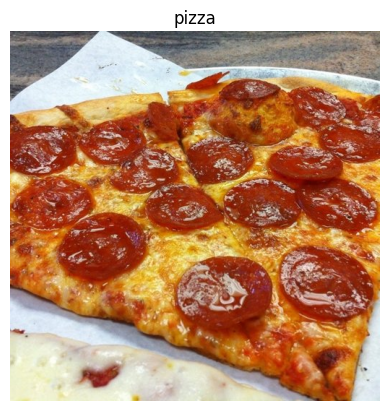

In [8]:
# View a random image from the training dataset
img = view_random_image(target_dir="pizza_steak/train/",
                        target_class="pizza")

In [9]:
# The images we've imported and plotted are actually giant arrays/tensors of different pixel values
import tensorflow as tf
tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 74,  71,  78],
        [ 71,  68,  75],
        [ 65,  64,  70],
        ...,
        [132, 124, 103],
        [137, 129, 106],
        [122, 114,  91]],

       [[ 94,  91,  98],
        [ 92,  89,  96],
        [ 87,  86,  92],
        ...,
        [143, 135, 114],
        [147, 139, 118],
        [137, 129, 108]],

       [[106, 103, 110],
        [101,  98, 105],
        [ 95,  92,  99],
        ...,
        [146, 137, 120],
        [147, 138, 121],
        [138, 130, 111]],

       ...,

       [[239, 240, 208],
        [239, 240, 208],
        [238, 239, 205],
        ...,
        [210, 224, 227],
        [211, 225, 228],
        [212, 226, 229]],

       [[242, 243, 211],
        [242, 243, 211],
        [241, 242, 208],
        ...,
        [212, 226, 229],
        [212, 226, 229],
        [213, 227, 230]],

       [[244, 245, 213],
        [244, 245, 213],
        [243, 244, 210],
        ...,
        [214, 228, 23

In [10]:
# View the image shape
img.shape # return width, height. colour channels

(512, 512, 3)

In [11]:
# Get all the pixel values between 0 and 1
img/255.

array([[[0.29019608, 0.27843137, 0.30588235],
        [0.27843137, 0.26666667, 0.29411765],
        [0.25490196, 0.25098039, 0.2745098 ],
        ...,
        [0.51764706, 0.48627451, 0.40392157],
        [0.5372549 , 0.50588235, 0.41568627],
        [0.47843137, 0.44705882, 0.35686275]],

       [[0.36862745, 0.35686275, 0.38431373],
        [0.36078431, 0.34901961, 0.37647059],
        [0.34117647, 0.3372549 , 0.36078431],
        ...,
        [0.56078431, 0.52941176, 0.44705882],
        [0.57647059, 0.54509804, 0.4627451 ],
        [0.5372549 , 0.50588235, 0.42352941]],

       [[0.41568627, 0.40392157, 0.43137255],
        [0.39607843, 0.38431373, 0.41176471],
        [0.37254902, 0.36078431, 0.38823529],
        ...,
        [0.57254902, 0.5372549 , 0.47058824],
        [0.57647059, 0.54117647, 0.4745098 ],
        [0.54117647, 0.50980392, 0.43529412]],

       ...,

       [[0.9372549 , 0.94117647, 0.81568627],
        [0.9372549 , 0.94117647, 0.81568627],
        [0.93333333, 0

### An end-to-end example

Let's build a convolutional neural network to find patterns in our images, more specifically we a need way to:

* Load our images
* Preprocess our images
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNN to our training data

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 0 & 1, also called as Scaling/Normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                            batch_size=32,
                                            target_size=(224, 224),
                                            class_mode="binary",
                                            seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation="relu",
                           input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile our CNN
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data, 
                        epochs=5, 
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


Epoch 1/5


47/47 [==============================] - 16s 310ms/step - loss: 0.5671 - accuracy: 0.7073 - val_loss: 0.3878 - val_accuracy: 0.8300
Epoch 2/5
47/47 [==============================] - 13s 277ms/step - loss: 0.4168 - accuracy: 0.8133 - val_loss: 0.3309 - val_accuracy: 0.8720
Epoch 3/5
47/47 [==============================] - 13s 277ms/step - loss: 0.3757 - accuracy: 0.8473 - val_loss: 0.2947 - val_accuracy: 0.8800
Epoch 4/5
47/47 [==============================] - 13s 277ms/step - loss: 0.3287 - accuracy: 0.8700 - val_loss: 0.3776 - val_accuracy: 0.8320
Epoch 5/5
47/47 [==============================] - 13s 277ms/step - loss: 0.2927 - accuracy: 0.8813 - val_loss: 0.3418 - val_accuracy: 0.8500


In [13]:
len(train_data)

47

In [14]:
model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 10)      280       
                                                                 
 conv2d_1 (Conv2D)           (None, 220, 220, 10)      910       
                                                                 
 max_pooling2d (MaxPooling2  (None, 110, 110, 10)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 108, 108, 10)      910       
                                                                 
 conv2d_3 (Conv2D)           (None, 106, 106, 10)      910       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 53, 53, 10)        0         
 g2D)                                                   